#problem-1

In [1]:
!pip install pandas numpy openpyxl

import pandas as pd
import numpy as np


In [4]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print("File Loaded:", file_name)

Saving BDM-DATASET.xlsx to BDM-DATASET.xlsx
File Loaded: BDM-DATASET.xlsx


#RMF Analysis

In [5]:
# Load sheets
sales = pd.read_excel('/content/BDM-DATASET.xlsx', sheet_name='Master_Sales_data')
customers = pd.read_excel('/content/BDM-DATASET.xlsx', sheet_name='Customer_Data')

# Merge customer names into sales
data = sales.merge(customers, on='Customer_ID', how='left')

# Convert date column to proper format (very important)
data['Transaction_Date'] = pd.to_datetime(data['Transaction_Date'], dayfirst=True)

# Calculate Total Spent per transaction
data['Total_Amount'] = data['Total_Selling_Price']

# Create RFM Table
rfm = data.groupby('Customer_ID').agg({
    'Transaction_Date': lambda x: (data['Transaction_Date'].max() - x.max()).days,  # Recency
    'Transaction_ID': 'count',       # Frequency
    'Total_Amount': 'sum'            # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']

# Add customer names
rfm = rfm.merge(customers[['Customer_ID', 'Customer_Name']], on='Customer_ID', how='left')

# Assign Scores (1–5 Scale)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

# Combined Score
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# Define Segment Rules
def segment(row):
    score = row['RFM_Score']

    if score >= 13:
        return 'Platinum Customers'           # Highest Priority Segment
    elif score >= 10:
        return 'Gold Customers'               # Loyal and Consistent
    elif score >= 8:
        return 'Growth Potential Customers'   # Can be nurtured to Loyal
    elif score >= 6:
        return 'Occasional Customers'         # Active but irregular
    elif score >= 4:
        return 'At-Risk Customers'            # Need re-engagement and follow-up
    else:
        return 'Dormant Customers'            # Very low recent activity or lost


rfm['Segment'] = rfm.apply(segment, axis=1)

# Sort by most valuable customers
rfm_sorted = rfm.sort_values(by='RFM_Score', ascending=False)

# Display final output
rfm_sorted

,Customer_ID,Recency,Frequency,Monetary,Customer_Name,R_Score,F_Score,M_Score,RFM_Score,Segment
19,C020,18,6,5950,Nimrat Nadkarni,5,5,5,15,Platinum Customers
195,C199,19,6,6350,Theodore Sundaram,5,5,5,15,Platinum Customers
620,C633,4,12,12450,Edhitha Guha,5,5,5,15,Platinum Customers
611,C624,18,6,8750,Yashodhara Om,5,5,5,15,Platinum Customers
596,C608,2,6,7500,Unnati Peri,5,5,5,15,Platinum Customers
...,...,...,...,...,...,...,...,...,...,...
20,C021,173,1,400,Siya Barad,1,1,1,3,Dormant Customers
314,C320,238,2,600,Xalak Chaudry,1,1,1,3,Dormant Customers
318,C324,289,2,1500,Chakrika Boase,1,1,1,3,Dormant Customers
139,C140,337,1,750,Fitan Rajan,1,1,1,3,Dormant Customers


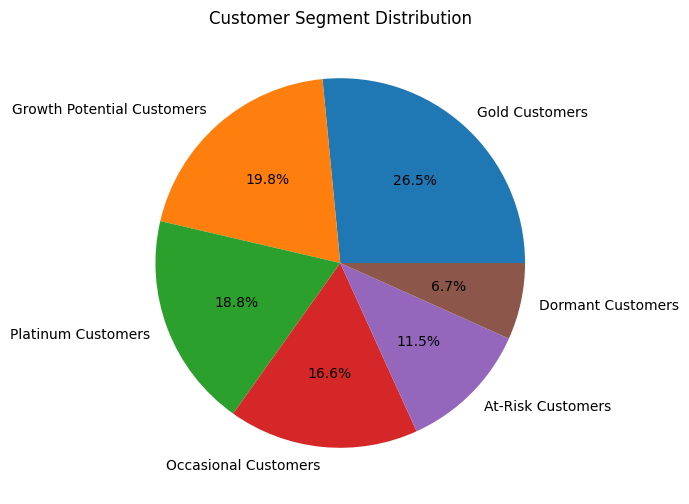

In [6]:
import matplotlib.pyplot as plt

# Count customers in each segment
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%')
plt.title('Customer Segment Distribution')
plt.show()

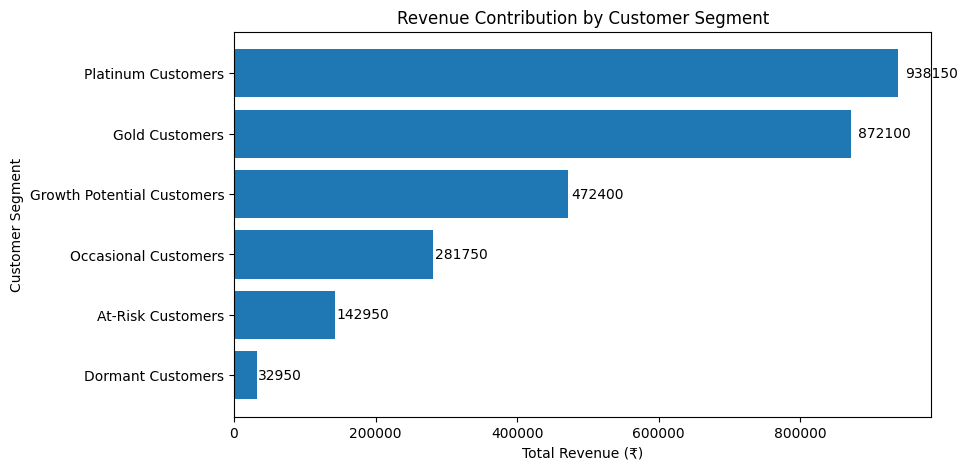

In [7]:
import matplotlib.pyplot as plt

segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values()

plt.figure(figsize=(9,5))
bars = plt.barh(segment_revenue.index, segment_revenue.values)

plt.xlabel('Total Revenue (₹)')
plt.ylabel('Customer Segment')
plt.title('Revenue Contribution by Customer Segment')

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2,
             f"{int(width)}", va='center')

plt.show()

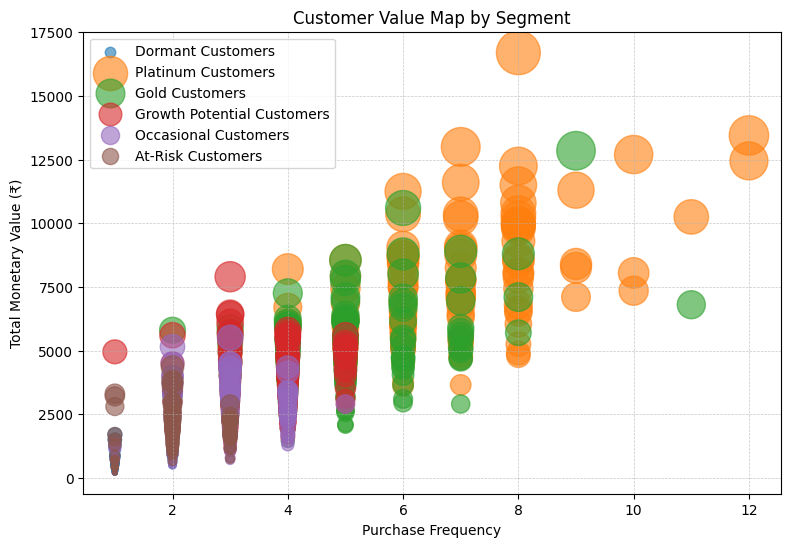

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

for segment in rfm['Segment'].unique():
    seg = rfm[rfm['Segment'] == segment]
    bubble = (seg['Monetary'] / rfm['Monetary'].max()) * 1000
    plt.scatter(seg['Frequency'], seg['Monetary'], s=bubble, alpha=0.6, label=segment)

plt.xlabel('Purchase Frequency')
plt.ylabel('Total Monetary Value (₹)')
plt.title('Customer Value Map by Segment')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()